<a href="https://colab.research.google.com/github/postnicov/ResazurinResorufin/blob/main/KubelkaMunk_ColorAnalysis_v6_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kubelka–Munk Spectral Reflectance and Color Analysis

**Version 6.5 — self-consistent D65 Lab/RGB and illuminant-C Munsell conversion**

D65 defines spectral integration, CIE Lab, sRGB, color distances, and color plates. Final D65 XYZ values are Bradford-adapted to illuminant C only for C-based Munsell conversion. Munsell hue number, value, and chroma are always rounded to 0.5. If the recovered raw hue is zero, its displayed hue is converted to the preceding sector’s 10 hue.


In [1]:
#@title Install and Import Required Packages
import importlib
import subprocess
import sys
import re
import warnings

required = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "scipy": "scipy", "colour-science": "colour"}
for pip_name, import_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f"{pip_name} already installed.")
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import minimize
import colour
from colour import SpectralDistribution, MSDS_CMFS, SDS_ILLUMINANTS
from colour import XYZ_to_Lab, XYZ_to_sRGB, Lab_to_XYZ
from colour.adaptation import chromatic_adaptation_VonKries

print("Python version:", sys.version.split()[0])
print("colour-science version:", colour.__version__)


numpy already installed.
pandas already installed.
matplotlib already installed.
scipy already installed.
Installing colour-science ...
Python version: 3.12.13
colour-science version: 0.4.7


In [2]:
#@title Set Target D65 CIE L*a*b* Parameters and Spectral Reference URL
target_L_star = 90.169 #@param {type:"number"}
target_a_star = -3.724 #@param {type:"number"}
target_b_star = -5.502 #@param {type:"number"}
spectral_reference_url = "https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/Rz6_5Ref.csv" #@param {type:"string"}

target_Lab_D65 = np.array([target_L_star, target_a_star, target_b_star], dtype=float)
print(f"Target D65 Lab: L*={target_Lab_D65[0]:.4f}, a*={target_Lab_D65[1]:.4f}, b*={target_Lab_D65[2]:.4f}")
print("Spectral reference URL:", spectral_reference_url)


Target D65 Lab: L*=90.1690, a*=-3.7240, b*=-5.5020
Spectral reference URL: https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/Rz6_5Ref.csv


In [3]:
#@title Set Savitzky-Golay Smoothing and Plot Parameters
savgol_window_length = 15 #@param {type:"integer"}
savgol_polynomial_order = 3 #@param {type:"integer"}
plot_font_size = 12 #@param {type:"integer"}
plot_font_family = "serif" #@param ["serif", "sans-serif", "monospace"]
plot_line_width = 1.5 #@param {type:"number"}

if savgol_window_length < 3 or savgol_window_length % 2 == 0:
    raise ValueError("savgol_window_length must be odd and at least 3.")
if savgol_polynomial_order < 0 or savgol_polynomial_order >= savgol_window_length:
    raise ValueError("savgol_polynomial_order must be non-negative and smaller than savgol_window_length.")

plt.rcParams.update({"font.size": plot_font_size, "font.family": plot_font_family, "lines.linewidth": plot_line_width, "axes.labelsize": plot_font_size, "axes.titlesize": plot_font_size, "legend.fontsize": plot_font_size, "xtick.labelsize": plot_font_size, "ytick.labelsize": plot_font_size})
print(f"Savitzky-Golay: window={savgol_window_length}, polynomial order={savgol_polynomial_order}")


Savitzky-Golay: window=15, polynomial order=3


Loaded 341 points: 360–700 nm


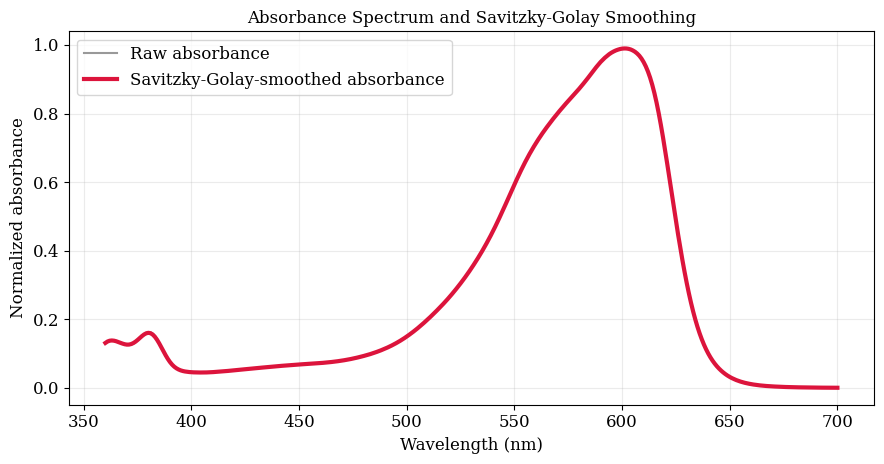

In [4]:
#@title Load and Smooth the Absorbance Spectrum
df = pd.read_csv(spectral_reference_url).dropna().sort_values("lambda").reset_index(drop=True)
if not {"lambda", "Absorbance"}.issubset(df.columns):
    raise ValueError("The CSV file must contain columns named 'lambda' and 'Absorbance'.")
wavelengths = df["lambda"].to_numpy(dtype=float)
absorbance_raw = df["Absorbance"].to_numpy(dtype=float)
if savgol_window_length > len(absorbance_raw):
    raise ValueError("savgol_window_length cannot exceed the number of spectrum points.")

absorbance_smooth = savgol_filter(absorbance_raw, window_length=savgol_window_length, polyorder=savgol_polynomial_order, mode="interp")
absorbance_smooth = np.clip(absorbance_smooth, 0.0, None)
print(f"Loaded {len(wavelengths)} points: {wavelengths.min():.0f}–{wavelengths.max():.0f} nm")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, absorbance_raw, color="0.60", lw=plot_line_width, label="Raw absorbance")
ax.plot(wavelengths, absorbance_smooth, color="crimson", lw=2 * plot_line_width, label="Savitzky-Golay-smoothed absorbance")
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized absorbance", title="Absorbance Spectrum and Savitzky-Golay Smoothing")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
#@title Define Kubelka-Munk, D65 Colorimetry, and C Munsell Functions

def scattering_coefficient(wavelengths, S0, s):
    return S0 * np.exp(-s * (np.asarray(wavelengths, dtype=float) - 360.0))


def kubelka_munk_reflectance(A, wavelengths, S0, s):
    if S0 <= 0 or s <= 0:
        raise ValueError("S0 and s must both be positive.")

    S_lambda = scattering_coefficient(wavelengths, S0, s)
    x = (
        np.clip(np.asarray(A, dtype=float), 0.0, None)
        / np.maximum(S_lambda, np.finfo(float).tiny)
    )

    # Numerically stable equivalent of:
    # R = 1 + x - sqrt(x**2 + 2*x)
    return np.clip(
        1.0 / (1.0 + x + np.sqrt(x * x + 2.0 * x)),
        0.0,
        1.0,
    )


OBSERVER = "CIE 1931 2 Degree Standard Observer"
CAT_TRANSFORM = "Bradford"

cmfs = MSDS_CMFS[OBSERVER]
illuminant_D65 = SDS_ILLUMINANTS["D65"]

xy_D65 = colour.CCS_ILLUMINANTS[OBSERVER]["D65"]
xy_C = colour.CCS_ILLUMINANTS[OBSERVER]["C"]

XYZ_w_D65 = colour.xy_to_XYZ(xy_D65)
XYZ_w_C = colour.xy_to_XYZ(xy_C)

HUE_SECTORS = ["R", "YR", "Y", "GY", "G", "BG", "B", "PB", "P", "RP"]


def reflectance_to_XYZ_D65(reflectance):
    sd = SpectralDistribution(
        dict(zip(wavelengths, reflectance)),
        name="Reflectance",
    )
    return colour.sd_to_XYZ(
        sd.align(cmfs.shape),
        cmfs=cmfs,
        illuminant=illuminant_D65,
    )


def XYZ_to_Lab_D65(XYZ_D65):
    return XYZ_to_Lab(XYZ_D65 / 100.0, illuminant=xy_D65)


def XYZ_to_RGB_D65(XYZ_D65):
    RGB_01 = np.clip(
        XYZ_to_sRGB(XYZ_D65 / 100.0, illuminant=xy_D65),
        0.0,
        1.0,
    )
    return np.rint(RGB_01 * 255.0).astype(int)


def adapt_XYZ_D65_to_C(XYZ_D65):
    return chromatic_adaptation_VonKries(
        XYZ_D65 / 100.0,
        XYZ_w_D65,
        XYZ_w_C,
        transform=CAT_TRANSFORM,
    )


def round_to_half(value):
    return np.floor(float(value) * 2.0 + 0.5) / 2.0


def half_string(value):
    rounded = round_to_half(value)
    return str(int(rounded)) if float(rounded).is_integer() else f"{rounded:.1f}"


def format_munsell_with_half_rounding(
    raw_munsell,
    zero_tolerance=0.25,
    ten_tolerance=0.25,
):
    """
    Round Munsell hue, value, and chroma to 0.5.

    A recovered sector-boundary hue is represented in canonical form as
    10 of the preceding sector:
        0.0PB -> 10B
        0.0B  -> 10BG
        0.0R  -> 10RP

    Values close to 10 are retained as 10 of their own sector because they
    already use the preceding-sector representation.
    """
    text = str(raw_munsell).strip().upper()

    chromatic = re.fullmatch(
        r"([+-]?(?:\d+(?:\.\d*)?|\.\d+))\s*([A-Z]+)\s+"
        r"([^\s/]+)\s*/\s*([^\s]+)",
        text,
    )
    neutral = re.fullmatch(r"N([0-9]+(?:\.[0-9]+)?)", text)

    if neutral:
        return f"N{half_string(neutral.group(1))}"

    if chromatic is None:
        return text

    hue_text, sector, value_text, chroma_text = chromatic.groups()

    raw_hue = float(hue_text)
    rounded_value = half_string(value_text)
    rounded_chroma = half_string(chroma_text)

    # Recovered 0.0 of a sector: change to the preceding sector at 10.
    if (
        np.isclose(raw_hue, 0.0, atol=zero_tolerance)
        and sector in HUE_SECTORS
    ):
        previous_sector = HUE_SECTORS[
            (HUE_SECTORS.index(sector) - 1) % len(HUE_SECTORS)
        ]
        return f"10{previous_sector} {rounded_value}/{rounded_chroma}"

    # Recovered values near 10 already use the canonical preceding-sector form.
    if np.isclose(raw_hue, 10.0, atol=ten_tolerance):
        return f"10{sector} {rounded_value}/{rounded_chroma}"

    return f"{half_string(raw_hue)}{sector} {rounded_value}/{rounded_chroma}"


def XYZ_D65_to_Munsell_C(XYZ_D65):
    """
    Convert final D65 XYZ to a C-based Munsell notation.

    D65 XYZ is first Bradford-adapted to illuminant C. The resulting
    Munsell hue/value/chroma is rounded to 0.5. A raw zero hue is rendered
    as 10 of the preceding sector.
    """
    try:
        XYZ_C = adapt_XYZ_D65_to_C(XYZ_D65)
        xyY_C = colour.XYZ_to_xyY(XYZ_C)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            raw_munsell = colour.xyY_to_munsell_colour(
                xyY_C,
                hue_decimals=3,
                value_decimals=3,
                chroma_decimals=3,
            )

        return format_munsell_with_half_rounding(raw_munsell)

    except (RuntimeError, ValueError, FloatingPointError):
        return "Unavailable (outside renotation domain)"


def evaluate_parameters(params):
    """Calculate the D65 quantities used in both optimization objectives."""
    S0, s = params

    R = kubelka_munk_reflectance(
        absorbance_smooth,
        wavelengths,
        S0,
        s,
    )
    XYZ_D65 = reflectance_to_XYZ_D65(R)
    Lab_D65 = XYZ_to_Lab_D65(XYZ_D65)
    RGB_D65 = XYZ_to_RGB_D65(XYZ_D65)

    return R, XYZ_D65, Lab_D65, RGB_D65

In [6]:
#@title Optimize Positive S0 and s: Full D65 L*a*b* Distance
bounds = [(1e-8, 100.0), (1e-10, 0.10)]
x0 = np.array([0.5, 0.001])

def full_Lab_D65_error(params):
    try:
        _, _, Lab_D65, _ = evaluate_parameters(params)
        return np.sum((Lab_D65 - target_Lab_D65) ** 2)
    except Exception:
        return 1e100

full_fit = minimize(full_Lab_D65_error, x0, method="L-BFGS-B", bounds=bounds, options={"ftol": 1e-14, "gtol": 1e-12, "maxiter": 5000})
S0_full, s_full = full_fit.x
R_full, XYZ_full_D65, Lab_full_D65, RGB_full_D65 = evaluate_parameters(full_fit.x)
dE_full_D65 = np.sqrt(full_fit.fun)

print("Full D65 L*a*b* optimization")
print(f"  Optimized S0 = {S0_full:.8f}")
print(f"  Optimized s  = {s_full:.8f} nm^-1")
print(f"  Achieved D65 Lab = ({Lab_full_D65[0]:.4f}, {Lab_full_D65[1]:.4f}, {Lab_full_D65[2]:.4f})")
print(f"  Achieved D65 RGB (0–255) = ({RGB_full_D65[0]}, {RGB_full_D65[1]}, {RGB_full_D65[2]})")
print(f"  D65 dE = {dE_full_D65:.4f}")


Full D65 L*a*b* optimization
  Optimized S0 = 100.00000000
  Optimized s  = 0.00596677 nm^-1
  Achieved D65 Lab = (93.1175, -0.4058, -8.3792)
  Achieved D65 RGB (0–255) = (226, 236, 251)
  D65 dE = 5.2898


In [7]:
#@title Optimize Positive S0 and s: D65 (a*, b*) Plane Only
def ab_plane_D65_error(params):
    try:
        _, _, Lab_D65, _ = evaluate_parameters(params)
        return np.sum((Lab_D65[1:] - target_Lab_D65[1:]) ** 2)
    except Exception:
        return 1e100

ab_fit = minimize(ab_plane_D65_error, x0, method="L-BFGS-B", bounds=bounds, options={"ftol": 1e-14, "gtol": 1e-12, "maxiter": 5000})
S0_ab, s_ab = ab_fit.x
R_ab, XYZ_ab_D65, Lab_ab_D65, RGB_ab_D65 = evaluate_parameters(ab_fit.x)
dE_ab_D65 = np.sqrt(ab_fit.fun)
dE_ab_full_Lab_D65 = np.linalg.norm(Lab_ab_D65 - target_Lab_D65)

print("D65 (a*, b*)-plane-only optimization")
print(f"  Optimized S0 = {S0_ab:.8f}")
print(f"  Optimized s  = {s_ab:.8f} nm^-1")
print(f"  Achieved D65 Lab = ({Lab_ab_D65[0]:.4f}, {Lab_ab_D65[1]:.4f}, {Lab_ab_D65[2]:.4f})")
print(f"  Achieved D65 RGB (0–255) = ({RGB_ab_D65[0]}, {RGB_ab_D65[1]}, {RGB_ab_D65[2]})")
print(f"  D65 dE_ab = {dE_ab_D65:.4f}")
print(f"  Full D65 Lab dE for this fit = {dE_ab_full_Lab_D65:.4f}")


D65 (a*, b*)-plane-only optimization
  Optimized S0 = 100.00000000
  Optimized s  = 0.00361641 nm^-1
  Achieved D65 Lab = (94.5382, 0.0870, -6.3140)
  Achieved D65 RGB (0–255) = (233, 240, 251)
  D65 dE_ab = 3.8966
  Full D65 Lab dE for this fit = 5.8543


In [8]:
#@title Convert Final D65 Colors to Rounded Illuminant-C Munsell Codes
XYZ_reference_D65 = Lab_to_XYZ(target_Lab_D65, illuminant=xy_D65) * 100.0
RGB_reference_D65 = XYZ_to_RGB_D65(XYZ_reference_D65)
Munsell_reference_C = XYZ_D65_to_Munsell_C(XYZ_reference_D65)
Munsell_full_C = XYZ_D65_to_Munsell_C(XYZ_full_D65)
Munsell_ab_C = XYZ_D65_to_Munsell_C(XYZ_ab_D65)

print("Final illuminant-C Munsell codes from Bradford-adapted D65 XYZ")
print("All Munsell components are rounded to 0.5; recovered zero hue is shown as preceding-sector 10 hue.")
print(f"  Reference target: {Munsell_reference_C}")
print(f"  Full D65 L*a*b* fit: {Munsell_full_C}")
print(f"  D65 (a*, b*)-plane fit: {Munsell_ab_C}")


Final illuminant-C Munsell codes from Bradford-adapted D65 XYZ
All Munsell components are rounded to 0.5; recovered zero hue is shown as preceding-sector 10 hue.
  Reference target: 10B 9/2
  Full D65 L*a*b* fit: 5PB 9.5/3
  D65 (a*, b*)-plane fit: 5.5PB 9.5/3


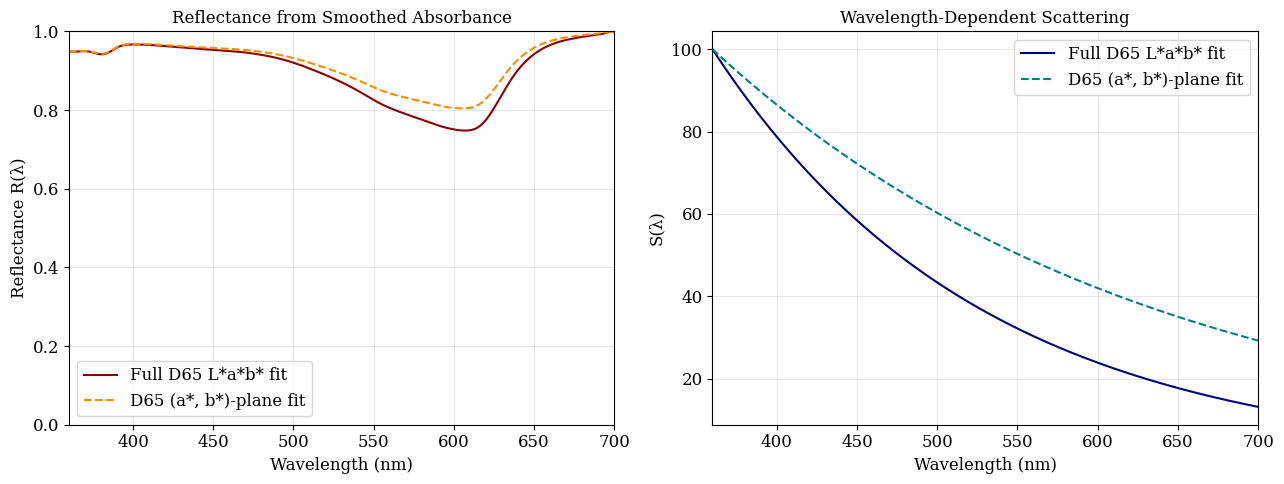

In [9]:
#@title Plot Smoothed Reflectance Spectra and Scattering Functions
S_full = scattering_coefficient(wavelengths, S0_full, s_full)
S_ab = scattering_coefficient(wavelengths, S0_ab, s_ab)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(wavelengths, R_full, color="darkred", label="Full D65 L*a*b* fit")
axes[0].plot(wavelengths, R_ab, color="darkorange", ls="--", label="D65 (a*, b*)-plane fit")
axes[0].set(xlabel="Wavelength (nm)", ylabel="Reflectance R(λ)", title="Reflectance from Smoothed Absorbance", ylim=(0, 1))
axes[0].set_xlim(wavelengths.min(), wavelengths.max())
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(wavelengths, S_full, color="navy", label="Full D65 L*a*b* fit")
axes[1].plot(wavelengths, S_ab, color="teal", ls="--", label="D65 (a*, b*)-plane fit")
axes[1].set(xlabel="Wavelength (nm)", ylabel="S(λ)", title="Wavelength-Dependent Scattering")
axes[1].set_xlim(wavelengths.min(), wavelengths.max())
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


                  Case         S0  s (nm^-1)    L* D65    a* D65    b* D65   dE D65  dE_ab D65   Munsell C  R D65 (0-255)  G D65 (0-255)  B D65 (0-255)
      Reference target        NaN        NaN 90.169000 -3.724000 -5.502000 0.000000   0.000000     10B 9/2            214            229            237
   Full D65 L*a*b* fit 100.000000   0.005967 93.117458 -0.405794 -8.379213 5.289825   4.391907   5PB 9.5/3            226            236            251
D65 (a*, b*)-plane fit 100.000000   0.003616 94.538172  0.087021 -6.313981 5.854303   3.896562 5.5PB 9.5/3            233            240            251

Final full D65 Lab color distance, dE = 5.2898
Final D65 a*b*-plane color distance, dE_ab = 3.8966


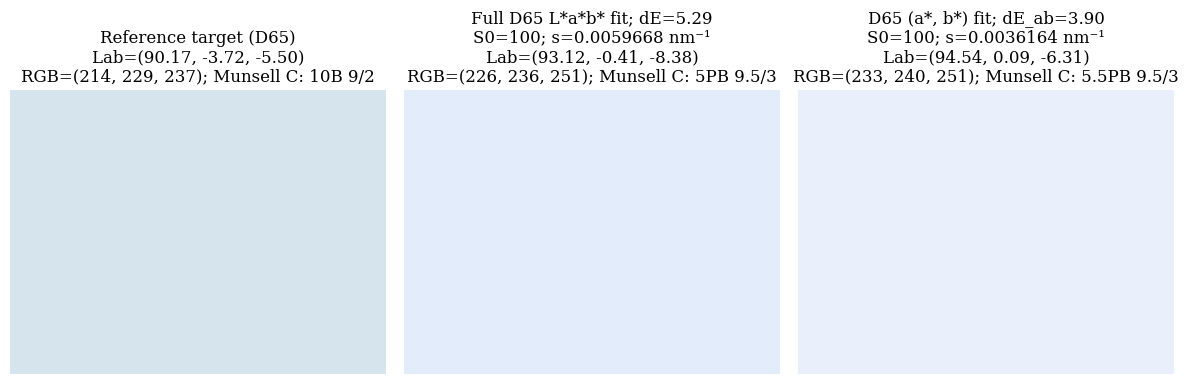

In [10]:
#@title Report D65 Color Results and Illuminant-C Munsell Codes
summary = pd.DataFrame({
    "Case": ["Reference target", "Full D65 L*a*b* fit", "D65 (a*, b*)-plane fit"],
    "S0": [np.nan, S0_full, S0_ab],
    "s (nm^-1)": [np.nan, s_full, s_ab],
    "L* D65": [target_Lab_D65[0], Lab_full_D65[0], Lab_ab_D65[0]],
    "a* D65": [target_Lab_D65[1], Lab_full_D65[1], Lab_ab_D65[1]],
    "b* D65": [target_Lab_D65[2], Lab_full_D65[2], Lab_ab_D65[2]],
    "dE D65": [0.0, dE_full_D65, dE_ab_full_Lab_D65],
    "dE_ab D65": [0.0, np.linalg.norm(Lab_full_D65[1:] - target_Lab_D65[1:]), dE_ab_D65],
    "Munsell C": [Munsell_reference_C, Munsell_full_C, Munsell_ab_C],
    "R D65 (0-255)": [RGB_reference_D65[0], RGB_full_D65[0], RGB_ab_D65[0]],
    "G D65 (0-255)": [RGB_reference_D65[1], RGB_full_D65[1], RGB_ab_D65[1]],
    "B D65 (0-255)": [RGB_reference_D65[2], RGB_full_D65[2], RGB_ab_D65[2]],
})
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"\nFinal full D65 Lab color distance, dE = {dE_full_D65:.4f}")
print(f"Final D65 a*b*-plane color distance, dE_ab = {dE_ab_D65:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = [RGB_reference_D65 / 255.0, RGB_full_D65 / 255.0, RGB_ab_D65 / 255.0]
titles = [
    f"Reference target (D65)\nLab=({target_Lab_D65[0]:.2f}, {target_Lab_D65[1]:.2f}, {target_Lab_D65[2]:.2f})\nRGB=({RGB_reference_D65[0]}, {RGB_reference_D65[1]}, {RGB_reference_D65[2]}); Munsell C: {Munsell_reference_C}",
    f"Full D65 L*a*b* fit; dE={dE_full_D65:.2f}\nS0={S0_full:.5g}; s={s_full:.5g} nm⁻¹\nLab=({Lab_full_D65[0]:.2f}, {Lab_full_D65[1]:.2f}, {Lab_full_D65[2]:.2f})\nRGB=({RGB_full_D65[0]}, {RGB_full_D65[1]}, {RGB_full_D65[2]}); Munsell C: {Munsell_full_C}",
    f"D65 (a*, b*) fit; dE_ab={dE_ab_D65:.2f}\nS0={S0_ab:.5g}; s={s_ab:.5g} nm⁻¹\nLab=({Lab_ab_D65[0]:.2f}, {Lab_ab_D65[1]:.2f}, {Lab_ab_D65[2]:.2f})\nRGB=({RGB_ab_D65[0]}, {RGB_ab_D65[1]}, {RGB_ab_D65[2]}); Munsell C: {Munsell_ab_C}",
]

for ax, colour_rgb, title in zip(axes, colors, titles):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=colour_rgb))
    ax.set(xlim=(0, 1), ylim=(0, 1), title=title)
    ax.axis("off")
plt.tight_layout()
plt.show()
